In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [12]:
df = pd.read_csv("cleaned_data1.csv")

In [13]:
df.head()

,Unnamed: 0,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [14]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [15]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Converting categorical columns using Label Encoder

In [17]:
label_encoder = LabelEncoder()

In [18]:
df['education'] = label_encoder.fit_transform(df['education'])

In [19]:
df['loan_status'] = label_encoder.fit_transform(df['loan_status'])

In [20]:
df['self_employed'] = label_encoder.fit_transform(df['self_employed'])

In [21]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [22]:
# here remove loan_id as it is an just a identifier

In [23]:
df.drop('loan_id', axis=1, inplace=True)

In [24]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


# Separate features and target

In [26]:
X = df.drop('loan_status', axis=1)   # features or independent variable

In [27]:
y = df['loan_status']       # target or dependent variable

In [28]:
X.shape

(4269, 11)

In [29]:
y.shape

(4269,)

# Train test split

In [30]:
from sklearn.model_selection import train_test_split

In [34]:
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)

In [35]:
len(train_x),len(train_y)

(3415, 3415)

In [36]:
len(test_x),len(test_y)

(854, 854)

# Feature scaling

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

In [39]:
X_train_scaled = scaler.fit_transform(train_x)

X_test_scaled = scaler.transform(test_x)

In [41]:
X_train_scaled

array([[ 1.51250774,  1.00263891, -1.01504731, ...,  2.04678575,
         0.07808278,  1.16041374],
       [-1.43500078,  1.00263891,  0.98517575, ...,  1.22311091,
         2.49843196,  0.88201987],
       [-0.84549907, -0.99736803, -1.01504731, ..., -0.8818359 ,
        -1.33923881, -1.31419838],
       ...,
       [ 0.92300603,  1.00263891,  0.98517575, ...,  1.29175048,
         1.47359943,  0.13963624],
       [-0.25599737,  1.00263891,  0.98517575, ..., -0.83607619,
         0.50327926,  1.4388076 ],
       [ 0.92300603, -0.99736803, -1.01504731, ..., -0.28695963,
         1.03750048, -0.10782497]], shape=(3415, 11))

# Convert back to dataframe

In [43]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=train_x.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=test_x.columns
)

# Now creating Logistic regression model for this dataset

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
model = LogisticRegression(max_iter=1000,random_state=42)

In [51]:
model.fit(train_x, train_y)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [54]:
y_pred=model.predict(test_x)
y_prob=model.predict_proba(test_x)[:,1]

In [55]:
print('Accuracy:',accuracy_score(test_y,y_pred))
print('Precision:',precision_score(test_y,y_pred))
print('Recall:',recall_score(test_y,y_pred))
print('F1:',f1_score(test_y,y_pred))
print('ROC AUC:',roc_auc_score(test_y,y_prob))
print(classification_report(test_y,y_pred))
print(confusion_matrix(test_y,y_pred))

Accuracy: 0.7985948477751756
Precision: 0.8016528925619835
Recall: 0.610062893081761
F1: 0.6928571428571428
ROC AUC: 0.8715326668544072
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       536
           1       0.80      0.61      0.69       318

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854

[[488  48]
 [124 194]]


In [57]:
import matplotlib.pyplot as plt

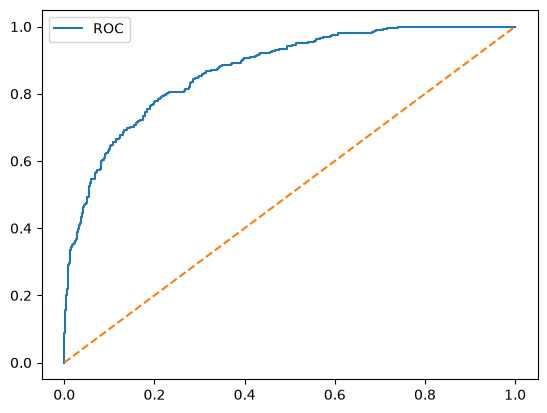

In [58]:
fpr,tpr,_=roc_curve(test_y,y_prob)
plt.plot(fpr,tpr,label='ROC')
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

In [59]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,StandardScaler().fit_transform(X),y,cv=cv)
print(scores,scores.mean())

[0.91569087 0.90163934 0.91686183 0.92271663 0.92379836] 0.9161414047678533
